In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import seaborn as sns
import pickle


from matplotlib.colors import ListedColormap



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [3]:
import warnings

warnings.simplefilter("ignore", FutureWarning)

#warnings.simplefilter("ignore", RuntimeWarning)


warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"squidpy\.pl\._spatial_utils"
)
import anndata
warnings.filterwarnings(
    "ignore",
    category=anndata._core.views.ImplicitModificationWarning
)

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


# dotplot of expression

In [6]:
FILE_NAME = "adata_combined_new.h5ad.final.filtered.addrelapse"
PATH2=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
adata_5k=sc.read_h5ad(PATH2)
adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]
adata_5k=adata_5k[adata_5k.obs["all_vs_core"]!="relapse"]


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST

  

In [7]:
# adata_5k

In [8]:
CATEGORY="lvl5_annotation"
NICHE_COLUMN   = "niche19"


In [9]:
# sc.pp.normalize_total(adata_5k, target_sum=1e4)
# sc.pp.log1p(adata_5k)
adata_5k = adata_5k[adata_5k.obs["niche19"]!="Nonspecific/folded"]

In [11]:
# # --------------------------------------------------
# # 1  Compute per-slide TRM subtype fractions
# # --------------------------------------------------

# TRM_TYPES = ["TRM_IL13+", "TRM_IL17+"]

# mask_trm = adata_5k.obs["lvl5_annotation"].isin(TRM_TYPES)

# # count TRM subtype cells per slide+niche
# df = (
#     adata_5k.obs.loc[mask_trm]
#     .groupby(["info_id6", NICHE_COLUMN, "lvl5_annotation"])
#     .size()
#     .reset_index(name="trm_cells")
# )

# # total cells per slide+niche (denominator)
# totals = (
#     adata_5k.obs
#     .groupby(["info_id6", NICHE_COLUMN])
#     .size()
#     .reset_index(name="total_cells")
# )

# df = df.merge(totals, on=["info_id6", NICHE_COLUMN])

# df["prop_TRM"] = df["trm_cells"] / df["total_cells"]


# # --------------------------------------------------
# # 2  Mean ± SEM per niche and TRM subtype
# # --------------------------------------------------

# stats = (
#     df.groupby([NICHE_COLUMN, "lvl5_annotation"])["prop_TRM"]
#       .agg(
#           mean="mean",
#           sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
#       )
#       .reset_index()
# )


# # --------------------------------------------------
# # 3  Keep top 7 niches (based on total TRM prevalence)
# # --------------------------------------------------

# order = (
#     stats.groupby(NICHE_COLUMN)["mean"]
#     .sum()
#     .sort_values(ascending=False)
#     .head(7)
#     .index
# )

# stats_top = stats[stats[NICHE_COLUMN].isin(order)]


# # --------------------------------------------------
# # 4  Plot
# # --------------------------------------------------

# plt.figure(figsize=(3,6))

# sns.barplot(
#     data=stats_top,
#     x=NICHE_COLUMN,
#     y="mean",
#     hue="lvl5_annotation",
#     order=order,
#     palette={
#         "TRM_IL13+": "blue",
#         "TRM_IL17+": "red"
#     },
#     width=0.6
# )

# ax = plt.gca()

# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.xticks(rotation=90, ha="center")
# plt.xlabel("Niche", labelpad=6)
# plt.ylabel("Fraction of TRM cells", labelpad=6)
# plt.title("")

# plt.legend(title="TRM subtype")

# plt.tight_layout()

# plt.savefig(
#     "fig4/4c_TRM_prevelance1.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

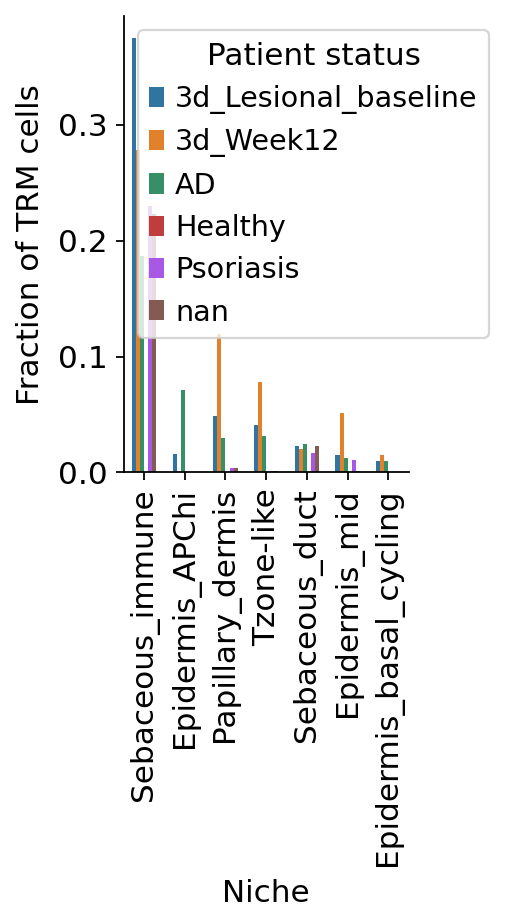

In [12]:
# --------------------------------------------------
# 1  Compute per-slide TRM fractions
# --------------------------------------------------

mask_trm = adata_5k.obs["lvl5_annotation"].astype(str).str.startswith("TRM_")

df = (
    adata_5k.obs.assign(is_TRM=mask_trm)
        .groupby(["info_id6", "Patient_status", NICHE_COLUMN])
        .agg(
            total_cells=("is_TRM", "size"),
            trm_cells=("is_TRM", "sum")
        )
        .reset_index()
)

df["prop_TRM"] = df["trm_cells"] / df["total_cells"]


# --------------------------------------------------
# 2  Mean ± SEM per niche and patient status
# --------------------------------------------------

stats = (
    df.groupby([NICHE_COLUMN, "Patient_status"])["prop_TRM"]
      .agg(
          mean="mean",
          sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
      )
      .reset_index()
)

# determine top niches using overall TRM prevalence
order = (
    df.groupby(NICHE_COLUMN)["prop_TRM"]
      .mean()
      .sort_values(ascending=False)
      .head(7)
      .index
)

stats_top = stats[stats[NICHE_COLUMN].isin(order)]


# --------------------------------------------------
# 3  Plot
# --------------------------------------------------

plt.figure(figsize=(3, 6))

sns.barplot(
    data=stats_top,
    x=NICHE_COLUMN,
    y="mean",
    hue="Patient_status",
    order=order,
    width=0.6,
    capsize=0.15
)

ax = plt.gca()

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=90, ha="center")

plt.xlabel("Niche", labelpad=6)
plt.ylabel("Fraction of TRM cells", labelpad=6)
plt.title("")

plt.legend(title="Patient status")

plt.tight_layout()

plt.savefig(
    "fig4/4c_TRM_prevelance1.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
{x:x for x in adata_5k.obs["Patient_status"].unique()}

{'AD': 'AD',
 'Psoriasis': 'Psoriasis',
 'nan': 'nan',
 'Healthy': 'Healthy',
 '3d_Lesional_baseline': '3d_Lesional_baseline',
 '3d_Week12': '3d_Week12'}

In [14]:
adata_5k.obs["Site_status"].value_counts()

Site_status
Lesional                            205777
Non-lesional                        192948
3D_Week12                           179026
3D_Lesional_baseline                153479
Week 12                             149279
Psoriasis_replicate_non-lesional     76048
Week 8 Psoriasis                     72092
Psoriasis_replicate_Lesional         60640
Healthy                              59315
Psoriasis_replicate_PostRx           49382
Day 14_HF                            30438
Name: count, dtype: int64

In [15]:
adata_5k.obs["plot"]=adata_5k.obs["Patient_status"].astype(str)+"_" + adata_5k.obs["Site_status"].astype(str)
{x:x for x in sorted(adata_5k.obs["plot"].unique())}

{'3d_Lesional_baseline_3D_Lesional_baseline': '3d_Lesional_baseline_3D_Lesional_baseline',
 '3d_Lesional_baseline_3D_Week12': '3d_Lesional_baseline_3D_Week12',
 '3d_Week12_3D_Week12': '3d_Week12_3D_Week12',
 'AD_Day 14_HF': 'AD_Day 14_HF',
 'AD_Lesional': 'AD_Lesional',
 'AD_Non-lesional': 'AD_Non-lesional',
 'AD_Week 12': 'AD_Week 12',
 'Healthy_Healthy': 'Healthy_Healthy',
 'Psoriasis_Lesional': 'Psoriasis_Lesional',
 'Psoriasis_Non-lesional': 'Psoriasis_Non-lesional',
 'Psoriasis_Week 8 Psoriasis': 'Psoriasis_Week 8 Psoriasis',
 'nan_Psoriasis_replicate_Lesional': 'nan_Psoriasis_replicate_Lesional',
 'nan_Psoriasis_replicate_PostRx': 'nan_Psoriasis_replicate_PostRx',
 'nan_Psoriasis_replicate_non-lesional': 'nan_Psoriasis_replicate_non-lesional'}

In [16]:
RENAME = {'3d_Lesional_baseline_3D_Lesional_baseline': '3d_Lesional_baseline_3D_Lesional_baseline',
 '3d_Lesional_baseline_3D_Week12': '3d_Lesional_baseline_3D_Week12',
 '3d_Week12_3D_Week12': '3d_Week12_3D_Week12',
 'AD_Day 14_HF': 'AD_Day 14_HF',
 'AD_Lesional': 'AD_Lesional',
 'AD_Non-lesional': 'AD_Non-lesional',
 'AD_Week 12': 'AD_Week 12',
 'Healthy_Healthy': 'Healthy_Healthy',
 'Psoriasis_Lesional': 'Psoriasis_Lesional',
 'Psoriasis_Non-lesional': 'Psoriasis_Non-lesional',
 'Psoriasis_Week 8 Psoriasis': 'Psoriasis_Week 8 Psoriasis',
 'nan_Psoriasis_replicate_Lesional': 'nan_Psoriasis_replicate_Lesional',
 'nan_Psoriasis_replicate_PostRx': 'nan_Psoriasis_replicate_PostRx',
 'nan_Psoriasis_replicate_non-lesional': 'nan_Psoriasis_replicate_non-lesional'}
adata_5k.obs["plot2"]=adata_5k.obs["plot"].map(RENAME)
adata_5k = adata_5k[adata_5k.obs["plot"].isin(['Psoriasis_Lesional', 'AD_Lesional', 'AD_Week 12',  ])]

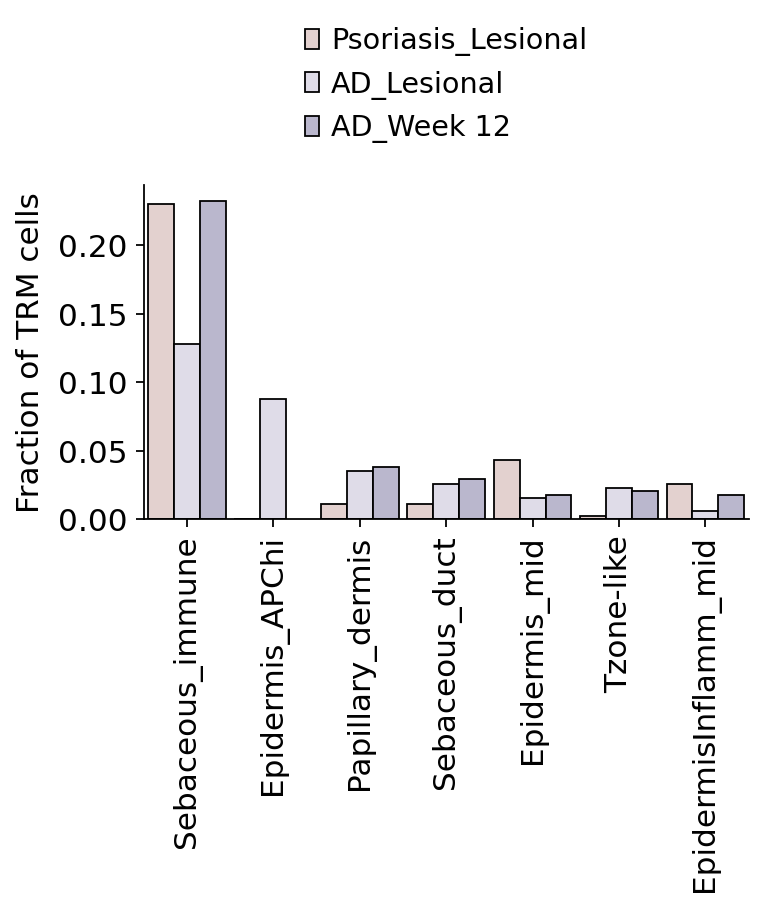

In [26]:
# --------------------------------------------------
# 1  Compute per-slide TRM fractions
# --------------------------------------------------

mask_trm = adata_5k.obs["lvl5_annotation"].astype(str).str.startswith("TRM_")

df = (
    adata_5k.obs.assign(is_TRM=mask_trm)
        .groupby(["info_id6", "plot2", NICHE_COLUMN])
        .agg(
            total_cells=("is_TRM", "size"),
            trm_cells=("is_TRM", "sum")
        )
        .reset_index()
)

df["prop_TRM"] = df["trm_cells"] / df["total_cells"]


# --------------------------------------------------
# 2  Mean ± SEM per niche and status
# --------------------------------------------------

stats = (
    df.groupby([NICHE_COLUMN, "plot2"])["prop_TRM"]
      .agg(
          mean="mean",
          sem=lambda x: x.std(ddof=1) / np.sqrt(len(x))
      )
      .reset_index()
)

order = (
    df.groupby(NICHE_COLUMN)["prop_TRM"]
      .mean()
      .sort_values(ascending=False)
      .head(7)
      .index
)

stats_top = stats[stats[NICHE_COLUMN].isin(order)]


# --------------------------------------------------
# 3  Plot
# --------------------------------------------------

plt.figure(figsize=(5, 6))

palette = {
    'AD_Lesional':        "#dedaea",
    'AD_Week 12':         "#b7b3d1",
    'Psoriasis_Lesional': "#e6cecc",
}
hue_order = ['Psoriasis_Lesional', 'AD_Lesional', 'AD_Week 12']

sns.barplot(
    data=stats_top,
    x=NICHE_COLUMN,
    y="mean",
    hue="plot2",
    hue_order=hue_order,
    order=order,
    palette=palette,
    width=.9,
    capsize=0.15,
    edgecolor="black",
    linewidth=0.8,
)
ax = plt.gca()

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=90, ha="center")

# remove x label
plt.xlabel("")

plt.ylabel("Fraction of TRM cells", labelpad=6)
plt.title("")

# legend formatting
plt.legend(
    frameon=False,
    title=None,
    bbox_to_anchor=(0.5, 1.05),   # move legend upward
    loc="lower center",
    ncol=1
)

plt.tight_layout()

plt.savefig(
    "fig4/4c_TRM_prevelance1.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [18]:
"AD_lesional": []

SyntaxError: illegal target for annotation (1136855581.py, line 1)

In [ ]:
# --------------------------------------------------
# 1  Compute per-slide TRM fractions
# --------------------------------------------------
mask_trm = adata_5k.obs["lvl5_annotation"].astype(str).str.startswith("TRM_")

df = (
    adata_5k.obs.assign(is_TRM=mask_trm)
        .groupby(["info_id6", NICHE_COLUMN])
        .agg(total_cells=("is_TRM", "size"),
             trm_cells  =("is_TRM", "sum"))
        .reset_index()
)
df["prop_TRM"] = df["trm_cells"] / df["total_cells"]

# --------------------------------------------------
# 2  Mean ± SEM per niche
# --------------------------------------------------
stats = (
    df.groupby(NICHE_COLUMN)["prop_TRM"]
      .agg(mean="mean",
           sem =lambda x: x.std(ddof=1) / np.sqrt(len(x)))
      .reset_index()
      .sort_values("mean", ascending=False)
)

# keep only the top-7 niches
stats_top = stats.head(7)

# --------------------------------------------------
# 3  Plot
# --------------------------------------------------
plt.figure(figsize=(3, 6))
sns.barplot(
    data=stats_top,
    x=NICHE_COLUMN,
    y="mean",
    order=stats_top[NICHE_COLUMN],   # preserve the sorted order
    yerr=stats_top["sem"],
    color="#f87a7b",
    width=0.6                     # <-- narrower bars (default ≈ 0.8)
)

ax = plt.gca()
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=90, ha="center")
plt.xlabel("Niche", labelpad=6)
plt.ylabel("Fraction of TRM cells", labelpad=6)
plt.title("")                    # no title
plt.tight_layout()
plt.savefig("fig4/4c_TRM_prevelance1.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
adata_5k.obs["Site_status"].value_counts()

In [ ]:
# --------------------------------------------------
# 1  Compute per-slide TRM fractions
# --------------------------------------------------
mask_trm = adata_5k.obs["lvl5_annotation"].astype(str).str.startswith("TRM_")

df = (
    adata_5k.obs.assign(is_TRM=mask_trm)
        .groupby(["info_id6", NICHE_COLUMN])
        .agg(total_cells=("is_TRM", "size"),
             trm_cells  =("is_TRM", "sum"))
        .reset_index()
)
df["prop_TRM"] = df["trm_cells"] / df["total_cells"]

# --------------------------------------------------
# 2  Mean ± SEM per niche
# --------------------------------------------------
stats = (
    df.groupby(NICHE_COLUMN)["prop_TRM"]
      .agg(mean="mean",
           sem =lambda x: x.std(ddof=1) / np.sqrt(len(x)))
      .reset_index()
      .sort_values("mean", ascending=False)
)

# keep only the top-7 niches
stats_top = stats.head(7)

# --------------------------------------------------
# 3  Plot
# --------------------------------------------------
plt.figure(figsize=(3, 6))
sns.barplot(
    data=stats_top,
    x=NICHE_COLUMN,
    y="mean",
    order=stats_top[NICHE_COLUMN],   # preserve the sorted order
    yerr=stats_top["sem"],
    color="#f87a7b",
    width=0.6                     # <-- narrower bars (default ≈ 0.8)
)

ax = plt.gca()
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=90, ha="center")
plt.xlabel("Niche", labelpad=6)
plt.ylabel("Fraction of TRM cells", labelpad=6)
plt.title("")                    # no title
plt.tight_layout()
plt.savefig("fig4/4c_TRM_prevelance1.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:

# --------------------------------------------------
# 1  Compute per-slide TRM fractions
# --------------------------------------------------
mask_trm = adata_5k.obs["lvl5_annotation"].astype(str).str.startswith("TRM_")

df = (
    adata_5k.obs.assign(is_TRM=mask_trm)
        .groupby(["info_id6", NICHE_COLUMN])
        .agg(total_cells=("is_TRM", "size"),
             trm_cells  =("is_TRM", "sum"))
        .reset_index()
)
df["prop_TRM"] = df["trm_cells"] / df["total_cells"]

# --------------------------------------------------
# 2  Mean ± SEM per niche (in %)
# --------------------------------------------------
stats = (
    df.groupby(NICHE_COLUMN)["prop_TRM"]
      .agg(mean="mean",
           sem =lambda x: x.std(ddof=1) / np.sqrt(len(x)))
      .reset_index()
)
stats["mean"] *= 100  # convert to percent
stats["sem"]  *= 100

stats = stats.sort_values("mean", ascending=False)
stats_top = stats.head(7)

# --------------------------------------------------
# 3  Plot (horizontal + x-axis on top)
# --------------------------------------------------
plt.figure(figsize=(4, 3))
sns.barplot(
    data=stats_top,
    x="mean",
    y=NICHE_COLUMN,
    order=stats_top[NICHE_COLUMN],
    xerr=stats_top["sem"],
    color="#f87a7b",
    width=0.6
)

ax = plt.gca()
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.grid(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.xlabel("TRM cells (%)", labelpad=6)
plt.ylabel("", labelpad=6)
plt.tight_layout()
plt.savefig("fig4/4c_TRM_prevelance1_smaller.pdf", dpi=300, bbox_inches="tight")

plt.show()